# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Ezra Angelita Ambarita]
- **Email:** [angelitaa917@gmail.com]
- **ID Dicoding:** [CDCC180D6X2241]


## Menentukan Pertanyaan Bisnis

1. Bagaimana perbandingan tren jumlah penyewaan sepeda per bulan antara tahun 2011 dan 2012, serta apakah terjadi peningkatan yang mencerminkan pertumbuhan bisnis selama periode tersebut?

2. Bagaimana perbedaan rata-rata jumlah penyewaan sepeda antara hari kerja dan hari libur selama periode 2011–2012, serta implikasinya terhadap strategi operasional layanan?

## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files
uploaded = files.upload()

Saving day.csv to day.csv


## Data Wrangling


### Gathering Data
Pada tahap ini dilakukan proses pengambilan dan pemuatan dataset yang akan digunakan dalam analisis. Dataset yang digunakan adalah Bike Sharing Dataset (day.csv) yang berisi data penyewaan sepeda harian selama tahun 2011–2012.

In [5]:
df = pd.read_csv("day.csv")
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Assesing Data

Pada tahap ini dilakukan pengecekan kualitas data untuk mengidentifikasi permasalahan yang mungkin terdapat dalam dataset.

Beberapa pengecekan yang dilakukan meliputi:
- Tipe data setiap kolom
- Missing values
- Duplicate data
- Statistik deskriptif

In [6]:
df.info()
df.isna().sum()
df.duplicated().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Berdasarkan hasil pengecekan, ditemukan beberapa hal berikut:

1. Kolom `dteday` masih bertipe object dan perlu diubah menjadi datetime.
2. Kolom `season` dan `weathersit` masih berupa angka sehingga kurang informatif.
3. Tidak ditemukan missing value dan duplicate data pada dataset.

### Cleaning Data

Berdasarkan permasalahan yang ditemukan pada tahap sebelumnya, dilakukan beberapa proses pembersihan data, yaitu:

1. Mengubah tipe data kolom `dteday` menjadi datetime
2. Mengubah nilai kategori menjadi lebih deskriptif
3. Menambahkan fitur baru untuk analisis

In [7]:
# Ubah tipe data
df["dteday"] = pd.to_datetime(df["dteday"])

# Feature engineering
df["month"] = df["dteday"].dt.month
df["year"] = df["dteday"].dt.year

# Mapping kategori
df["season"] = df["season"].map({
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
})

df["weathersit"] = df["weathersit"].map({
    1: "Clear",
    2: "Mist",
    3: "Light Rain/Snow",
    4: "Heavy Rain/Snow"
})

## EXPLORATORY DATA ANALYSIS (EDA)

### Pertanyaan 1: Tren penyewaan sepeda 2011 vs 2012



In [8]:
# Menambahkan kolom tahun
df['dteday'] = pd.to_datetime(df['dteday'])
df['year'] = df['dteday'].dt.year

# Total Penyewaan per Tahun
df.groupby('year')['cnt'].sum()

,cnt
year,
2011,1243103
2012,2049576


In [9]:
# Rata-rata per Tahun
df.groupby('year')['cnt'].mean()

,cnt
year,
2011,3405.761644
2012,5599.934426


In [10]:
# Tren Bulanan (untuk analisis lanjutan)
df['month'] = df['dteday'].dt.month
df.groupby(['year', 'month'])['cnt'].sum()

year  month
2011  1         38189
      2         48215
      3         64045
      4         94870
      5        135821
      6        143512
      7        141341
      8        136691
      9        127418
      10       123511
      11       102167
      12        87323
2012  1         96744
      2        103137
      3        164875
      4        174224
      5        195865
      6        202830
      7        203607
      8        214503
      9        218573
      10       198841
      11       152664
      12       123713
Name: cnt, dtype: int64

### Insight EDA 1

Terdapat peningkatan jumlah penyewaan sepeda pada tahun 2012 dibandingkan tahun 2011, yang menunjukkan adanya pertumbuhan penggunaan layanan dari waktu ke waktu. Selain itu, terdapat pola fluktuasi bulanan yang mengindikasikan adanya faktor musiman dalam penggunaan sepeda.

### Pertanyaan 2: Perbandingan Rata-rata Penyewaan Sepeda: Working Day vs Holiday







In [11]:
# Distribusi Data
df['workingday'].value_counts()



,count
workingday,
1,500
0,231


In [12]:
# Rata-rata Penyewaan
df.groupby('workingday')['cnt'].mean()


,cnt
workingday,
0,4330.168831
1,4584.820000


In [13]:
# Total Penyewaan
df.groupby('workingday')['cnt'].sum()

,cnt
workingday,
0,1000269
1,2292410


In [14]:
# Perbandingan Langsung
work_avg = df[df['workingday'] == 1]['cnt'].mean()
holiday_avg = df[df['workingday'] == 0]['cnt'].mean()

print("Working Day:", work_avg)
print("Holiday:", holiday_avg)

Working Day: 4584.82
Holiday: 4330.168831168831


### Insight EDA 2

Hasil analisis menunjukkan bahwa rata-rata penyewaan sepeda pada hari kerja lebih tinggi dibandingkan hari libur. Hal ini mengindikasikan bahwa sepeda lebih banyak digunakan sebagai alat transportasi harian (commuting) dibandingkan untuk rekreasi.

## Visualization & Explanatory Analysis

Pada tahap ini dilakukan eksplorasi data untuk menjawab pertanyaan bisnis yang telah ditentukan. Analisis difokuskan pada tren penyewaan sepeda dari waktu ke waktu serta perbedaan penyewaan antara hari kerja dan hari libur.

### Pertanyaan 1: Tren Penyewaan Sepeda Bulanan (2011 vs 2012)

Analisis ini bertujuan untuk melihat bagaimana perkembangan jumlah penyewaan sepeda setiap bulan serta membandingkan pola antara tahun 2011 dan 2012.

In [15]:
monthly_trend = df.groupby(["year", "month"])["cnt"].sum().reset_index()
monthly_trend.head()

,year,month,cnt
0,2011,1,38189
1,2011,2,48215
2,2011,3,64045
3,2011,4,94870
4,2011,5,135821


### Visualisasi 1

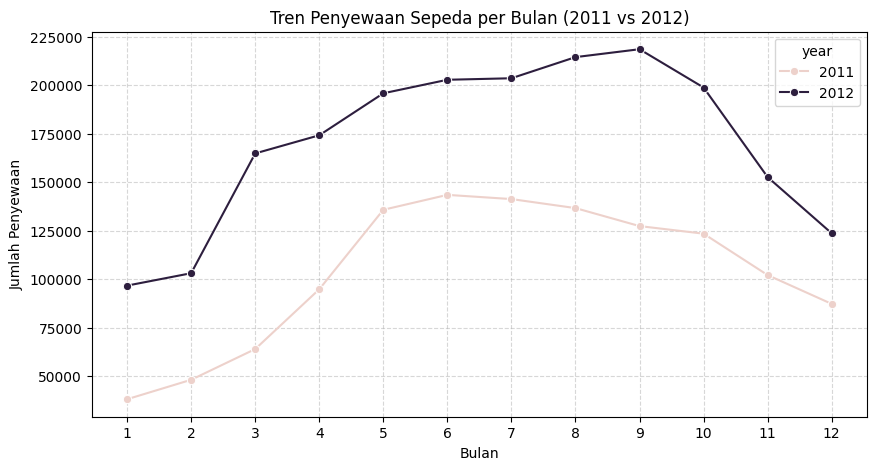

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_trend,
    x="month",
    y="cnt",
    hue="year",
    marker="o"
)

plt.title("Tren Penyewaan Sepeda per Bulan (2011 vs 2012)")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Penyewaan")
plt.xticks(range(1,13))
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

### Insight

Terlihat bahwa jumlah penyewaan sepeda pada tahun 2012 secara umum lebih tinggi dibandingkan tahun 2011. Selain itu, terdapat pola peningkatan pada bulan-bulan tertentu yang menunjukkan adanya tren musiman dalam penggunaan sepeda.

### Pertanyaan 2: Perbandingan Penyewaan: Hari Kerja vs Hari Libur

Analisis ini bertujuan untuk mengetahui perbedaan tingkat penyewaan sepeda antara hari kerja dan hari libur.

In [17]:
workingday_analysis = df.groupby("workingday")["cnt"].mean().reset_index()
workingday_analysis

,workingday,cnt
0,0,4330.168831
1,1,4584.820000


### Visualisasi 2

   workingday          cnt
0           0  4330.168831
1           1  4584.820000


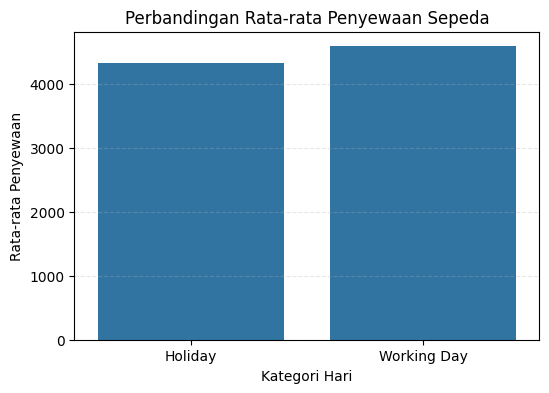

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. buat data dulu
workingday_analysis = df.groupby("workingday")["cnt"].mean().reset_index()

# 2. cek data
print(workingday_analysis)

# 3. visualisasi
plt.figure(figsize=(6,4))

sns.barplot(
    data=workingday_analysis,
    x="workingday",
    y="cnt"
)

plt.xticks([0,1], ["Holiday", "Working Day"])
plt.title("Perbandingan Rata-rata Penyewaan Sepeda")
plt.xlabel("Kategori Hari")
plt.ylabel("Rata-rata Penyewaan")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

### Insight

Rata-rata jumlah penyewaan sepeda pada hari kerja lebih tinggi dibandingkan hari libur. Hal ini menunjukkan bahwa sepeda lebih sering digunakan sebagai sarana transportasi harian dibandingkan untuk rekreasi.

## Analisis Lanjutan:

## Grouping berdasarkan intensitas penggunaan

In [25]:
df["usage_level"] = pd.cut(df["cnt"],
                           bins=[0, 2000, 5000, df["cnt"].max()],
                           labels=["Low", "Medium", "High"])
df["usage_level"].value_counts()

,count
usage_level,
Medium,347
High,286
Low,98


### Visualisasi

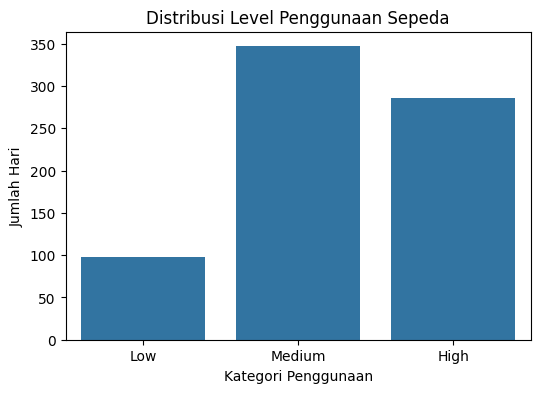

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="usage_level", order=["Low","Medium","High"])
plt.title("Distribusi Level Penggunaan Sepeda")
plt.xlabel("Kategori Penggunaan")
plt.ylabel("Jumlah Hari")
plt.show()

### Insight

Mayoritas hari memiliki tingkat penggunaan Medium, menunjukkan bahwa bike sharing digunakan secara stabil sepanjang tahun dengan beberapa lonjakan pada hari tertentu. Hal ini menunjukkan demand tidak hanya musiman, tetapi cukup konsisten.

## Grouping Berdasarkan Suhu (temp)

In [27]:
df["temp_group"] = pd.cut(
    df["temp"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Cold", "Normal", "Hot"]
)

df["temp_group"].value_counts()

,count
temp_group,
Normal,342
Hot,254
Cold,135


### Visualisasi

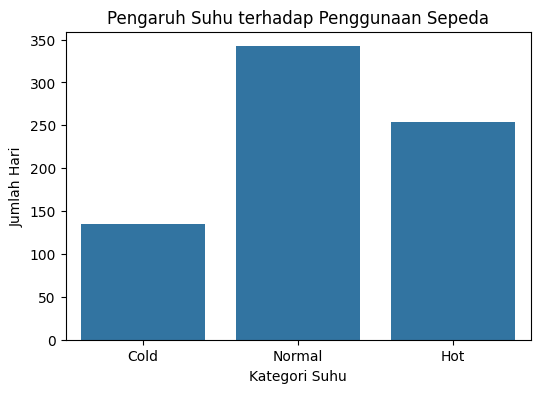

In [28]:
plt.figure(figsize=(6,4))
sns.barplot(x=df["temp_group"].value_counts().index,
            y=df["temp_group"].value_counts().values)

plt.title("Pengaruh Suhu terhadap Penggunaan Sepeda")
plt.xlabel("Kategori Suhu")
plt.ylabel("Jumlah Hari")
plt.show()

### Insight

Penggunaan sepeda paling tinggi terjadi pada kondisi suhu “Normal”, menunjukkan bahwa cuaca sangat mempengaruhi keputusan pengguna dalam menyewa sepeda. Pada suhu terlalu dingin atau panas, aktivitas penyewaan cenderung menurun.

## Clustering

In [34]:
threshold = df["cnt"].quantile(0.75)

df["demand_cluster"] = df["cnt"].apply(
    lambda x: "High Demand" if x > threshold else "Low Demand"
)

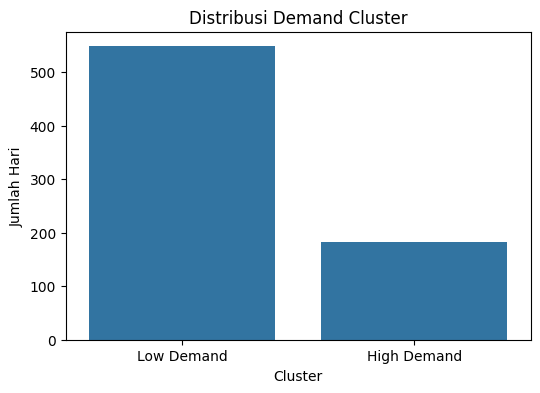

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="demand_cluster",
              order=df["demand_cluster"].value_counts().index)

plt.title("Distribusi Demand Cluster")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Hari")

plt.show()

### Insight

Hasil clustering berdasarkan kuantil 75% menunjukkan bahwa hanya sebagian kecil hari yang masuk kategori High Demand, yaitu sekitar 25% hari dengan jumlah penyewaan tertinggi. Hal ini mengindikasikan bahwa lonjakan penggunaan sepeda tidak terjadi secara merata, melainkan hanya pada periode tertentu.

# Conclusion

Berdasarkan hasil analisis data yang telah saya lakukan, diperoleh beberapa temuan utama sebagai berikut:


- **Conclusion pertanyaan 1:** (Bagaimana tren penyewaan 2011 vs 2012)

Hasil analisis menunjukkan bahwa terjadi peningkatan jumlah penyewaan sepeda dari tahun 2011 ke tahun 2012. Tren bulanan memperlihatkan bahwa hampir seluruh bulan pada tahun 2012 memiliki jumlah penyewaan yang lebih tinggi dibandingkan tahun sebelumnya. Hal ini mengindikasikan adanya pertumbuhan bisnis yang positif serta peningkatan minat pengguna terhadap layanan bike sharing.

- **Conclusion pertanyaan 2:** Perbedaan Workingday vs Holiday

Berdasarkan hasil analisis, rata-rata penyewaan sepeda pada hari kerja lebih tinggi dibandingkan hari libur. Hal ini menunjukkan bahwa sepeda lebih sering digunakan sebagai sarana transportasi harian dibandingkan untuk kebutuhan rekreasi. Pola ini mencerminkan bahwa pengguna utama layanan ini adalah pekerja atau individu dengan aktivitas rutin.

### Kesimpulan Umum

Secara keseluruhan, permintaan penyewaan sepeda dipengaruhi oleh faktor waktu dan aktivitas pengguna, dengan tren pertumbuhan yang positif serta dominasi penggunaan pada hari kerja.

# Recommendation

Berdasarkan temuan yang diperoleh, berikut beberapa rekomendasi strategis yang dapat diterapkan:


**Rekomendasi Action Item:**
# - Rekomendasi untuk Pertanyaan 1
1.   **Perencanaan kapasitas berbasis tren pertumbuhan**

Mengingat adanya peningkatan signifikan dari tahun 2011 ke 2012, perusahaan disarankan untuk menambah jumlah armada sepeda secara bertahap guna mengantisipasi pertumbuhan permintaan di masa mendatang.

2.  **Optimasi operasional pada periode dengan permintaan tinggi**

Berdasarkan pola bulanan, perusahaan dapat mengidentifikasi bulan dengan permintaan tinggi dan memastikan ketersediaan sepeda pada periode tersebut untuk menghindari kekurangan layanan.

3.  **Pemanfaatan tren historis untuk forecasting**

Data historis dapat digunakan untuk membuat prediksi permintaan di masa depan, sehingga distribusi sepeda dapat dilakukan secara lebih efisien dan tepat sasaran.

# - Rekomendasi untuk Pertanyaan 2
1.  **Fokus distribusi sepeda pada hari kerja**

Karena penyewaan lebih tinggi pada hari kerja, perusahaan perlu memastikan distribusi sepeda lebih banyak di area dengan aktivitas tinggi seperti perkantoran dan pusat kota.

2.  **Strategi peningkatan penggunaan pada hari libur**

Untuk meningkatkan peminjaman pada hari libur, perusahaan dapat menawarkan promo khusus seperti diskon, paket keluarga, atau program wisata berbasis sepeda.

3.  **Penyesuaian strategi pemasaran berdasarkan pola penggunaan**

Hari kerja dapat difokuskan pada pengguna rutin (commuter), sedangkan hari libur dapat ditargetkan untuk pengguna rekreasi melalui kampanye pemasaran yang berbeda.

In [36]:
df.to_csv("main_data.csv", index=False)